## 1. Import Statements

In [1]:
# !pip install pytransform3d
# !pip install cycler

In [2]:
import os
import numpy as np
import cv2

from tqdm import tqdm
import time
import matplotlib.pyplot as plt

import pytransform3d.transformations as pt
import pytransform3d.trajectories as ptr
import pytransform3d.rotations as pr
import pytransform3d.camera as pc

from cycler import cycle

## 2. Camera Class

In [3]:
class CameraPoses():
    
    def __init__(self, data_dir, skip_frames, intrinsic):
        
        self.K = intrinsic
        self.extrinsic = np.array(((1,0,0,0),(0,1,0,0),(0,0,1,0)))
        self.P = self.K @ self.extrinsic
        # Maximum features we want to detect
        self.orb = cv2.ORB_create(3000)
        FLANN_INDEX_LSH = 6
        index_params = dict(algorithm=FLANN_INDEX_LSH, table_number=6, key_size=12, multi_probe_level=1)
        search_params = dict(checks=50)
        self.flann = cv2.FlannBasedMatcher(indexParams=index_params, searchParams=search_params)
        
        self.world_points = []

        self.current_pose = None
        
    @staticmethod
    def _load_images(filepath, skip_frames):
    
        image_paths = [os.path.join(filepath, file) for file in sorted(os.listdir(filepath))]
        images = []
        
        for path in tqdm(image_paths[::skip_frames]):
            img = cv2.imread(path)
            if img is not None:
                #images.append(cv2.resize(img, (640,480)))
                images.append(img)
                
        return images
    

    @staticmethod
    def _form_transf(R, t):
        
        T = np.eye(4, dtype=np.float64)
        T[:3, :3] = R
        T[:3, 3] = t
        
        return T

    def get_world_points(self):
        return np.array(self.world_points)
    
    def get_matches(self, img1, img2):
   
        # Find the keypoints and descriptors with ORB
        kp1, des1 = self.orb.detectAndCompute(img1, None)
        kp2, des2 = self.orb.detectAndCompute(img2, None)
        # Find matches
        if len(kp1) > 6 and len(kp2) > 6:
            matches = self.flann.knnMatch(des1, des2, k=2)

            # Find the matches there do not have a to high distance
            good_matches = []
            try:
                for m, n in matches:
                    if m.distance < 0.5 * n.distance:
                        good_matches.append(m)
            except ValueError:
                pass
            
            # Draw matches
            img_matches = np.empty((max(img1.shape[0], img2.shape[0]), img1.shape[1] + img2.shape[1], 3), dtype=np.uint8)
            #cv2.drawMatches(img1, kp1, img2, kp2, good_matches, img_matches, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    
            #cv2.imshow('Good Matches', img_matches)
            #cv2.waitKey(50)
            
            # Get the image points form the good matches
            #q1 = [kp1[m.queryIdx] for m in good_matches]
            #q2 = [kp2[m.trainIdx] for m in good_matches]
            q1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
            q2 = np.float32([kp2[m.trainIdx].pt for m in good_matches])
        
            return q1, q2
        else:
            return None, None

    def get_pose(self, q1, q2):
    
        # Essential matrix
        E, mask = cv2.findEssentialMat(q1, q2, self.K)

        # Decompose the Essential matrix into R and t
        R, t = self.decomp_essential_mat_old(E, q1, q2)

        # Get transformation matrix
        transformation_matrix = self._form_transf(R, np.squeeze(t))
        
        return transformation_matrix


    def decomp_essential_mat(self, E, q1, q2):

        R1, R2, t = cv2.decomposeEssentialMat(E)
        T1 = self._form_transf(R1,np.ndarray.flatten(t))
        T2 = self._form_transf(R2,np.ndarray.flatten(t))
        T3 = self._form_transf(R1,np.ndarray.flatten(-t))
        T4 = self._form_transf(R2,np.ndarray.flatten(-t))
        transformations = [T1, T2, T3, T4]
        
        # Homogenize K
        K = np.concatenate((self.K, np.zeros((3,1)) ), axis = 1)

        # List of projections
        projections = [K @ T1, K @ T2, K @ T3, K @ T4]

        np.set_printoptions(suppress=True)

        # print ("\nTransform 1\n" +  str(T1))
        # print ("\nTransform 2\n" +  str(T2))
        # print ("\nTransform 3\n" +  str(T3))
        # print ("\nTransform 4\n" +  str(T4))

        positives = []
        for P, T in zip(projections, transformations):
            hom_Q1 = cv2.triangulatePoints(P, P, q1.T, q2.T)
            hom_Q2 = T @ hom_Q1
            # Un-homogenize
            Q1 = hom_Q1[:3, :] / hom_Q1[3, :]
            Q2 = hom_Q2[:3, :] / hom_Q2[3, :]
             
            total_sum = sum(Q2[2, :] > 0) + sum(Q1[2, :] > 0)
            relative_scale = np.mean(np.linalg.norm(Q1.T[:-1] - Q1.T[1:], axis=-1)/
                                     np.linalg.norm(Q2.T[:-1] - Q2.T[1:], axis=-1))
            positives.append(total_sum + relative_scale)
            

        # Decompose the Essential matrix using built in OpenCV function
        # Form the 4 possible transformation matrix T from R1, R2, and t
        # Create projection matrix using each T, and triangulate points hom_Q1
        # Transform hom_Q1 to second camera using T to create hom_Q2
        # Count how many points in hom_Q1 and hom_Q2 with positive z value
        # Return R and t pair which resulted in the most points with positive z

        max = np.argmax(positives)
        if (max == 2):
            # print(-t)
            return R1, np.ndarray.flatten(-t)
        elif (max == 3):
            # print(-t)
            return R2, np.ndarray.flatten(-t)
        elif (max == 0):
            # print(t)
            return R1, np.ndarray.flatten(t)
        elif (max == 1):
            # print(t)
            return R2, np.ndarray.flatten(t)
        
        
    def decomp_essential_mat_old(self, E, q1, q2):
        def sum_z_cal_relative_scale(R, t):
            # Get the transformation matrix
            T = self._form_transf(R, t)
            # Make the projection matrix
            P = np.matmul(np.concatenate((self.K, np.zeros((3, 1))), axis=1), T)

            # Triangulate the 3D points
            hom_Q1 = cv2.triangulatePoints(self.P, P, q1.T, q2.T)
            # Also seen from cam 2
            hom_Q2 = np.matmul(T, hom_Q1)

            # Un-homogenize
            Q1 = hom_Q1[:3, :] / hom_Q1[3, :]
            Q2 = hom_Q2[:3, :] / hom_Q2[3, :]
            
            #self.world_points.append(Q1)

            # Find the number of points there has positive z coordinate in both cameras
            sum_of_pos_z_Q1 = sum(Q1[2, :] > 0)
            sum_of_pos_z_Q2 = sum(Q2[2, :] > 0)

            # Form point pairs and calculate the relative scale
            relative_scale = np.mean(np.linalg.norm(Q1.T[:-1] - Q1.T[1:], axis=-1)/
                                     np.linalg.norm(Q2.T[:-1] - Q2.T[1:], axis=-1))
            return sum_of_pos_z_Q1 + sum_of_pos_z_Q2, relative_scale

        # Decompose the essential matrix
        R1, R2, t = cv2.decomposeEssentialMat(E)
        t = np.squeeze(t)

        # Make a list of the different possible pairs
        pairs = [[R1, t], [R1, -t], [R2, t], [R2, -t]]

        # Check which solution there is the right one
        z_sums = []
        relative_scales = []
        for R, t in pairs:
            z_sum, scale = sum_z_cal_relative_scale(R, t)
            z_sums.append(z_sum)
            relative_scales.append(scale)

        # Select the pair there has the most points with positive z coordinate
        right_pair_idx = np.argmax(z_sums)
        right_pair = pairs[right_pair_idx]
        relative_scale = relative_scales[right_pair_idx]
        R1, t = right_pair
        t = t * relative_scale
        
        T = self._form_transf(R1, t)
        # Make the projection matrix
        P = np.matmul(np.concatenate((self.K, np.zeros((3, 1))), axis=1), T)

        # Triangulate the 3D points
        hom_Q1 = cv2.triangulatePoints(P, P, q1.T, q2.T)
        # Also seen from cam 2
        hom_Q2 = np.matmul(T, hom_Q1)

        # Un-homogenize
        Q1 = hom_Q1[:3, :] / hom_Q1[3, :]
        Q2 = hom_Q2[:3, :] / hom_Q2[3, :]
        
        self.world_points.append(Q1)

        return [R1, t]

## 3. Parameters and Path

https://github.com/niconielsen32/ComputerVision/tree/master/LiveCameraTrajectory

In [4]:
with open('./utils/intrinsicNew.npy', 'rb') as f:
    intrinsic = np.load(f)

In [6]:
intrinsic

array([[470.08108521,   0.        , 278.19215297],
       [  0.        , 520.09613037, 233.85179557],
       [  0.        ,   0.        ,   1.        ]])

In [7]:
skip_frames = 2
data_dir = ''
vo = CameraPoses(data_dir, skip_frames, intrinsic)

gt_path = []
estimated_path = []
camera_pose_list = []
start_pose = np.ones((3,4))
start_translation = np.zeros((3,1))
start_rotation = np.identity(3)
start_pose = np.concatenate((start_rotation, start_translation), axis=1)
#print("Start pose: ", start_pose)

## 4. Real-Time Capture

In [35]:
cap = cv2.VideoCapture(0)

process_frames = False
old_frame = None
new_frame = None
frame_counter = 0

cur_pose = start_pose
  
while cap.isOpened():
    
    # Capture frame-by-frame
    ret, new_frame = cap.read()
    
    frame_counter += 1
    
    start = time.perf_counter()
    
    if process_frames and ret:
        q1, q2 = vo.get_matches(old_frame, new_frame)
        if q1 is not None:
            if len(q1) > 50 and len(q2) > 50:
                transf = vo.get_pose(q1, q2)
                cur_pose = cur_pose @ transf
                
        hom_array = np.array([[0,0,0,1]])
        hom_camera_pose = np.concatenate((cur_pose,hom_array), axis=0)
        camera_pose_list.append(hom_camera_pose)
        estimated_path = np.append(estimated_path,(cur_pose[0, 3], cur_pose[2, 3]))
        
        estimated_camera_pose_x, estimated_camera_pose_y = cur_pose[0, 3], cur_pose[2, 3]

    elif process_frames and ret is False:
        break
    
    old_frame = new_frame
    
    process_frames = True
    
    end = time.perf_counter()
    
    total_time = end - start
    fps = 1 / total_time
    
    cv2.putText(new_frame, f'FPS: {int(fps)}', (20,50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
    
    cv2.putText(new_frame, str(np.round(cur_pose[0, 0],2)), (260,50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 1)
    cv2.putText(new_frame, str(np.round(cur_pose[0, 1],2)), (340,50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 1)
    cv2.putText(new_frame, str(np.round(cur_pose[0, 2],2)), (420,50), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 1)
    cv2.putText(new_frame, str(np.round(cur_pose[1, 0],2)), (260,90), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 1)
    cv2.putText(new_frame, str(np.round(cur_pose[1, 1],2)), (340,90), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 1)
    cv2.putText(new_frame, str(np.round(cur_pose[1, 2],2)), (420,90), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 1)
    cv2.putText(new_frame, str(np.round(cur_pose[2, 0],2)), (260,130), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 1)
    cv2.putText(new_frame, str(np.round(cur_pose[2, 1],2)), (340,130), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 1)
    cv2.putText(new_frame, str(np.round(cur_pose[2, 2],2)), (420,130), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 1)
    
    cv2.putText(new_frame, str(np.round(cur_pose[0, 3],2)), (540,50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 1)
    cv2.putText(new_frame, str(np.round(cur_pose[1, 3],2)), (540,90), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 1)
    cv2.putText(new_frame, str(np.round(cur_pose[2, 3],2)), (540,130), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 1)
    
    
    cv2.imshow("img", new_frame)
    
    #if frame_counter % 20 == 0:
        #print("FPS: ", fps)
        #print("Frames: ", frame_counter)
    
    # Press Q on keyboard to  exit
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

# When everything done, release the video capture object
cap.release()
cv2.destroyAllWindows()

C:\Users\vikas\AppData\Local\Temp\ipykernel_8740\485707712.py:204: RuntimeWarning: invalid value encountered in matmul
  P = np.matmul(np.concatenate((self.K, np.zeros((3, 1))), axis=1), T)
C:\Users\vikas\AppData\Local\Temp\ipykernel_8740\485707712.py:209: RuntimeWarning: invalid value encountered in matmul
  hom_Q2 = np.matmul(T, hom_Q1)
C:\Users\vikas\AppData\Local\Temp\ipykernel_8740\117654585.py:24: RuntimeWarning: invalid value encountered in matmul
  cur_pose = cur_pose @ transf


In [36]:
cap.release()
cv2.destroyAllWindows()

## 4. Plotting Results

ValueError: Expected rotation matrix, but it failed the test for inversion by transposition. np.dot(R, R.T) gives array([[nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan]])

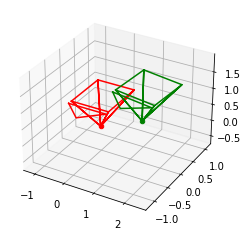

In [37]:
"""for i in tqdm(range(number_of_frames)):

    if i == 0:
        cur_pose = start_pose
    else:
        q1, q2 = vo.get_matches(i)
        if len(q1) > 20 and len(q2) > 20:
            transf = vo.get_pose(q1, q2)
            cur_pose = cur_pose @ transf
    
    hom_array = np.array([[0,0,0,1]])
    hom_camera_pose = np.concatenate((cur_pose,hom_array), axis=0)
    camera_pose_list.append(hom_camera_pose)
    estimated_path.append((cur_pose[0, 3], cur_pose[2, 3]))
    
    estimated_camera_pose_x, estimated_camera_pose_y = cur_pose[0, 3], cur_pose[2, 3]
"""

number_of_frames = 20
image_size = np.array([640, 480])
#image_size = np.array([1920, 1080])

plt.figure()
#ax = pt.plot_transform()
ax = plt.axes(projection='3d')

camera_pose_poses = np.array(camera_pose_list)


key_frames_indices = np.linspace(0, len(camera_pose_poses) - 1, number_of_frames, dtype=int)
colors = cycle("rgb")

for i, c in zip(key_frames_indices, colors):
    pc.plot_camera(ax, vo.K, camera_pose_poses[i],
                   sensor_size=image_size, c=c)


plt.show()

take_every_th_camera_pose = 2

estimated_path = np.array(estimated_path[::take_every_th_camera_pose])

plt.plot(estimated_path[:,0],estimated_path[:,1])
plt.show()